In [1]:
!nvidia-smi

Sun Feb 15 18:44:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:03:00.0 Off |                    0 |
| N/A   34C    P0             71W /  400W |       1MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import sys
sys.path.append('./src')

import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

import os
# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)



srcdir = os.path.join(home, "gigalens/src/")

['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', './src', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


This notebook may take quite a bit longer than the quickstart notebook. We set $n_{max}=8$ for the shapelets because this is the minimal number needed to capture the spiral arms features on the source galaxy, resulting in slower modeling. This is in part due to the higher memory pressure associated with a large number of shapelets components.

In [3]:
import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
import matplotlib as mpl
from matplotlib import pyplot as plt
from corner import corner

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic, shapelets
from gigalens.jax.profiles.mass import epl, shear, sis

tfd = tfp.distributions

2026-02-15 18:45:48.989350: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771209949.143720 1411323 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771209949.182349 1411323 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771209949.517556 1411323 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771209949.517582 1411323 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771209949.517584 1411323 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Load the data. The ground truth parameters are in `truth`. Various hyperparameters, including the noise scale and exposure time are fixed.

The PSF is generated from `TinyTim` for HST F140W band, and has been supersampled to the pixel scale of 0.065.

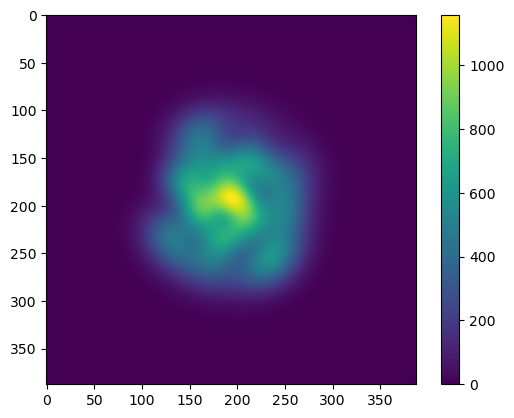

In [4]:
import gigalens
root = gigalens.__path__[0]
img = plt.imread(f'{root}/assets/M101.jpeg')
img = img[:,131:-131]
img = jnp.sqrt(img[...,1].astype(np.float32))
img -= np.median(img[:20,:20])
img *= 100
from skimage.transform import downscale_local_mean
img = downscale_local_mean(img, (5,5))
img = np.pad(img, [(100, 100), (100, 100)], mode='constant')
grid = jnp.linspace(-1,1,len(img)).astype(np.float32)
xx,yy = jnp.meshgrid(grid,grid)
xx, yy = xx[jnp.newaxis,...,jnp.newaxis], yy[jnp.newaxis,...,jnp.newaxis]
n_max = 8
shp = shapelets.Shapelets(n_max=n_max, interpolate=False, use_lstsq=True)
components = jnp.squeeze(shp.light(xx, yy, beta=0.13, center_x=0, center_y=0))
X = components.reshape((shp.depth, -1))
Y = img.flatten()
sol, resid, _, _ = jnp.linalg.lstsq(X.T, Y)
plt.imshow((sol@X).reshape(img.shape))
plt.colorbar()

In [5]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.0), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(0, 0.025),
                center_y=tfd.Normal(0, 0.025),
            )
        ),
    ]
)

amp_prior = {key: tfd.Normal(0,500/float(jnp.sqrt(i+1))) for i, key in enumerate(shapelets.Shapelets(n_max)._amp_names)}
source_light_params = dict(
    beta=tfd.LogNormal(jnp.log(0.1), 0.15),
    center_x=tfd.Normal(0, 0.01),
    center_y=tfd.Normal(0, 0.01)
)

source_light_prior = tfd.JointDistributionSequential([tfd.JointDistributionNamed(source_light_params)])

prior = tfd.JointDistributionSequential(
    [lens_prior, source_light_prior]
)

In [6]:
seed = 0
key = jax.random.PRNGKey(seed)
truth = prior.sample(1,seed=key)
truth[1][0] = {**truth[1][0], 
               **{f'amp{str(i).zfill(2)}': jnp.array([sol[i]]) for i in range(shp.depth)}, 
               'beta': jnp.array([0.08], dtype=jnp.float32),
              }

In [7]:
import gigalens
root = gigalens.__path__[0] + '/assets'
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=60, supersample=1)
phys_model = PhysicalModel([epl.EPL(), shear.Shear()], [], [shapelets.Shapelets(n_max=n_max, use_lstsq=False, interpolate=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = lens_sim.simulate(truth)
err_map = np.sqrt(0.1**2 + np.clip(observed_img, 0, np.inf)/200)
np.random.seed(1)
observed_img += np.random.normal(scale=err_map)

phys_model = PhysicalModel([epl.EPL(), shear.Shear()], [], [shapelets.Shapelets(n_max=n_max, use_lstsq=True, interpolate=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
prob_model = BackwardProbModel(prior, observed_img, background_rms=0.1, exp_time=200)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

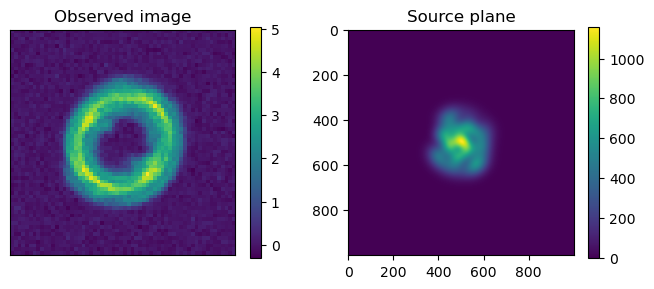

In [8]:
plt.figure(figsize=(8,3))
plt.subplot(121)
plt.imshow(observed_img)
plt.title('Observed image')
plt.colorbar() 
plt.xticks([])
plt.yticks([])
plt.subplot(122)
shp = shapelets.Shapelets(n_max=n_max, interpolate=False, use_lstsq=False)
grid = np.linspace(-1,1,1000).astype(np.float32)
a, b = np.meshgrid(grid,grid)
ret = shp.light(a[np.newaxis,...,np.newaxis], b[np.newaxis,...,np.newaxis], **truth[1][0])
plt.imshow(np.squeeze(ret))
plt.title('Source plane')
plt.grid(False)
plt.colorbar()

Begin fitting:

In [9]:
fitter = ModellingSequence(phys_model, prob_model, sim_config)

See $\S2.3$: Maximum a Posteriori Estimate

In [14]:
n_map = 100
optimizer = optax.adabelief(1e-2, b1=0.95, b2=0.99)
best, lp, chisq = fitter.MAP(optimizer=optimizer, n_samples=n_map, num_steps=150, seed=0)

Chi-squared: 0.956: 100%|██████████| 150/150 [00:10<00:00, 13.99it/s]


Final Chi-squared: 0.95623


See $\S2.4$: Variational Inference

In [15]:
opt = optax.adabelief(1e-2, b1=0.95, b2=0.99)
q_z, losses = fitter.SVI(optimizer=optimizer, start=best, n_vi=500, num_steps=350)

2026-02-15 18:48:47.525197: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-02-15 18:48:47.525346: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-02-15 18:48:47.525371: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-02-15 18:48:47.525393: W external/xla/xla/service/gpu/au

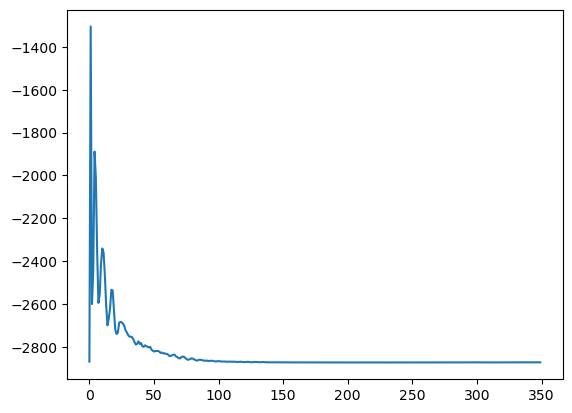

In [16]:
plt.plot(losses)

See $\S2.5$: Hamiltonian Monte Carlo

In [17]:
samples = fitter.HMC(q_z, n_hmc=50, init_eps=0.3, init_l=3, max_leapfrog_steps=300,
                                   num_burnin_steps=250, num_results=750,pbar_interval=25)

2026-02-15 18:49:55.872466: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-02-15 18:49:55.872566: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-02-15 18:49:55.872593: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-02-15 18:49:55.872619: W external/xla/xla/service/gpu/au

Sampling took 37.1s


In [39]:
from mclmc_alt import MCLMC
default_start = jnp.diag(jnp.ones((9,))) * 1e-3
no_SVI_qz = tfd.MultivariateNormalTriL(loc=jnp.squeeze(best), scale_tril=default_start)
mclmc_samples = MCLMC(model_seq, no_SVI_qz, n_hmc=48, num_burnin_steps=500, num_results=1500, progress_bar=True, continuous_adaptation=True)

Burnin Time: 106.19777631000034


Sampling took 192.75917428999674 s


In [26]:
hmc_samples = samples.transpose((1, 2, 0, 3)).reshape((48, 750, 9))

In [40]:
from blackjax.diagnostics import potential_scale_reduction, effective_sample_size


mclmc_rhat= potential_scale_reduction(mclmc_samples)
mclmc_ess = effective_sample_size(mclmc_samples)

hmc_rhat = potential_scale_reduction(hmc_samples)
hmc_ess = effective_sample_size(hmc_samples)

In [41]:
print("MCLMC Rhats:", mclmc_rhat)
print("HMC Rhats:",hmc_rhat)

MCLMC Rhats: [0.9999452  0.99995863 0.9999379  0.9999836  1.000001   1.0000925
 1.0000026  1.0000185  0.99997807]
HMC Rhats: [1.0007775 1.0010054 1.0008196 1.0010623 1.0007097 1.0005764 1.0008459
 1.0006377 1.0010458]


In [42]:
print("MCLMC ESS:", mclmc_ess)
print("HMC ESS:",hmc_ess)

MCLMC ESS: [37736.31  37662.977 37334.21  36745.645 36797.234 37281.46  36755.55
 37158.887 37717.03 ]
HMC ESS: [14021.204 15892.804 17317.35  17287.723 18575.436 21085.895 19776.236
 13684.54  15342.831]


In [20]:
Rhat= tfp.mcmc.potential_scale_reduction(samples, independent_chain_ndims=2)
ESS = tfp.mcmc.effective_sample_size(samples, cross_chain_dims=[1,2])
for i, rh in enumerate(Rhat):
    print(i,rh,ESS[i])

0 1.0016158 13906.734
1 1.0020815 15724.448
2 1.0017017 17181.346
3 1.0021977 17179.1
4 1.0014772 18449.729
5 1.0012048 20860.346
6 1.0017555 19633.979
7 1.0013303 13348.931
8 1.0021641 14783.119


Create a corner plot with sampling results:

In [21]:
num_params = len(Rhat)
smp = samples.reshape((-1, num_params))
smp_physical = prob_model.bij.forward(list(smp.T))

dict_indices = [(0, 0), (1, 0)]
label_prefixes = ["", "src_"]

labels = np.hstack([[label_prefixes[i] + key for key in smp_physical[i][j].keys()] for (i,j) in dict_indices])
plt_samples = np.vstack(
    [jnp.array(list(smp_physical[i][j].values())) for (i,j) in dict_indices]
).T

markers = np.hstack([np.squeeze(list(truth[0][0].values())),[truth[1][0][label].item() for label in ['center_y','center_x','beta']]])

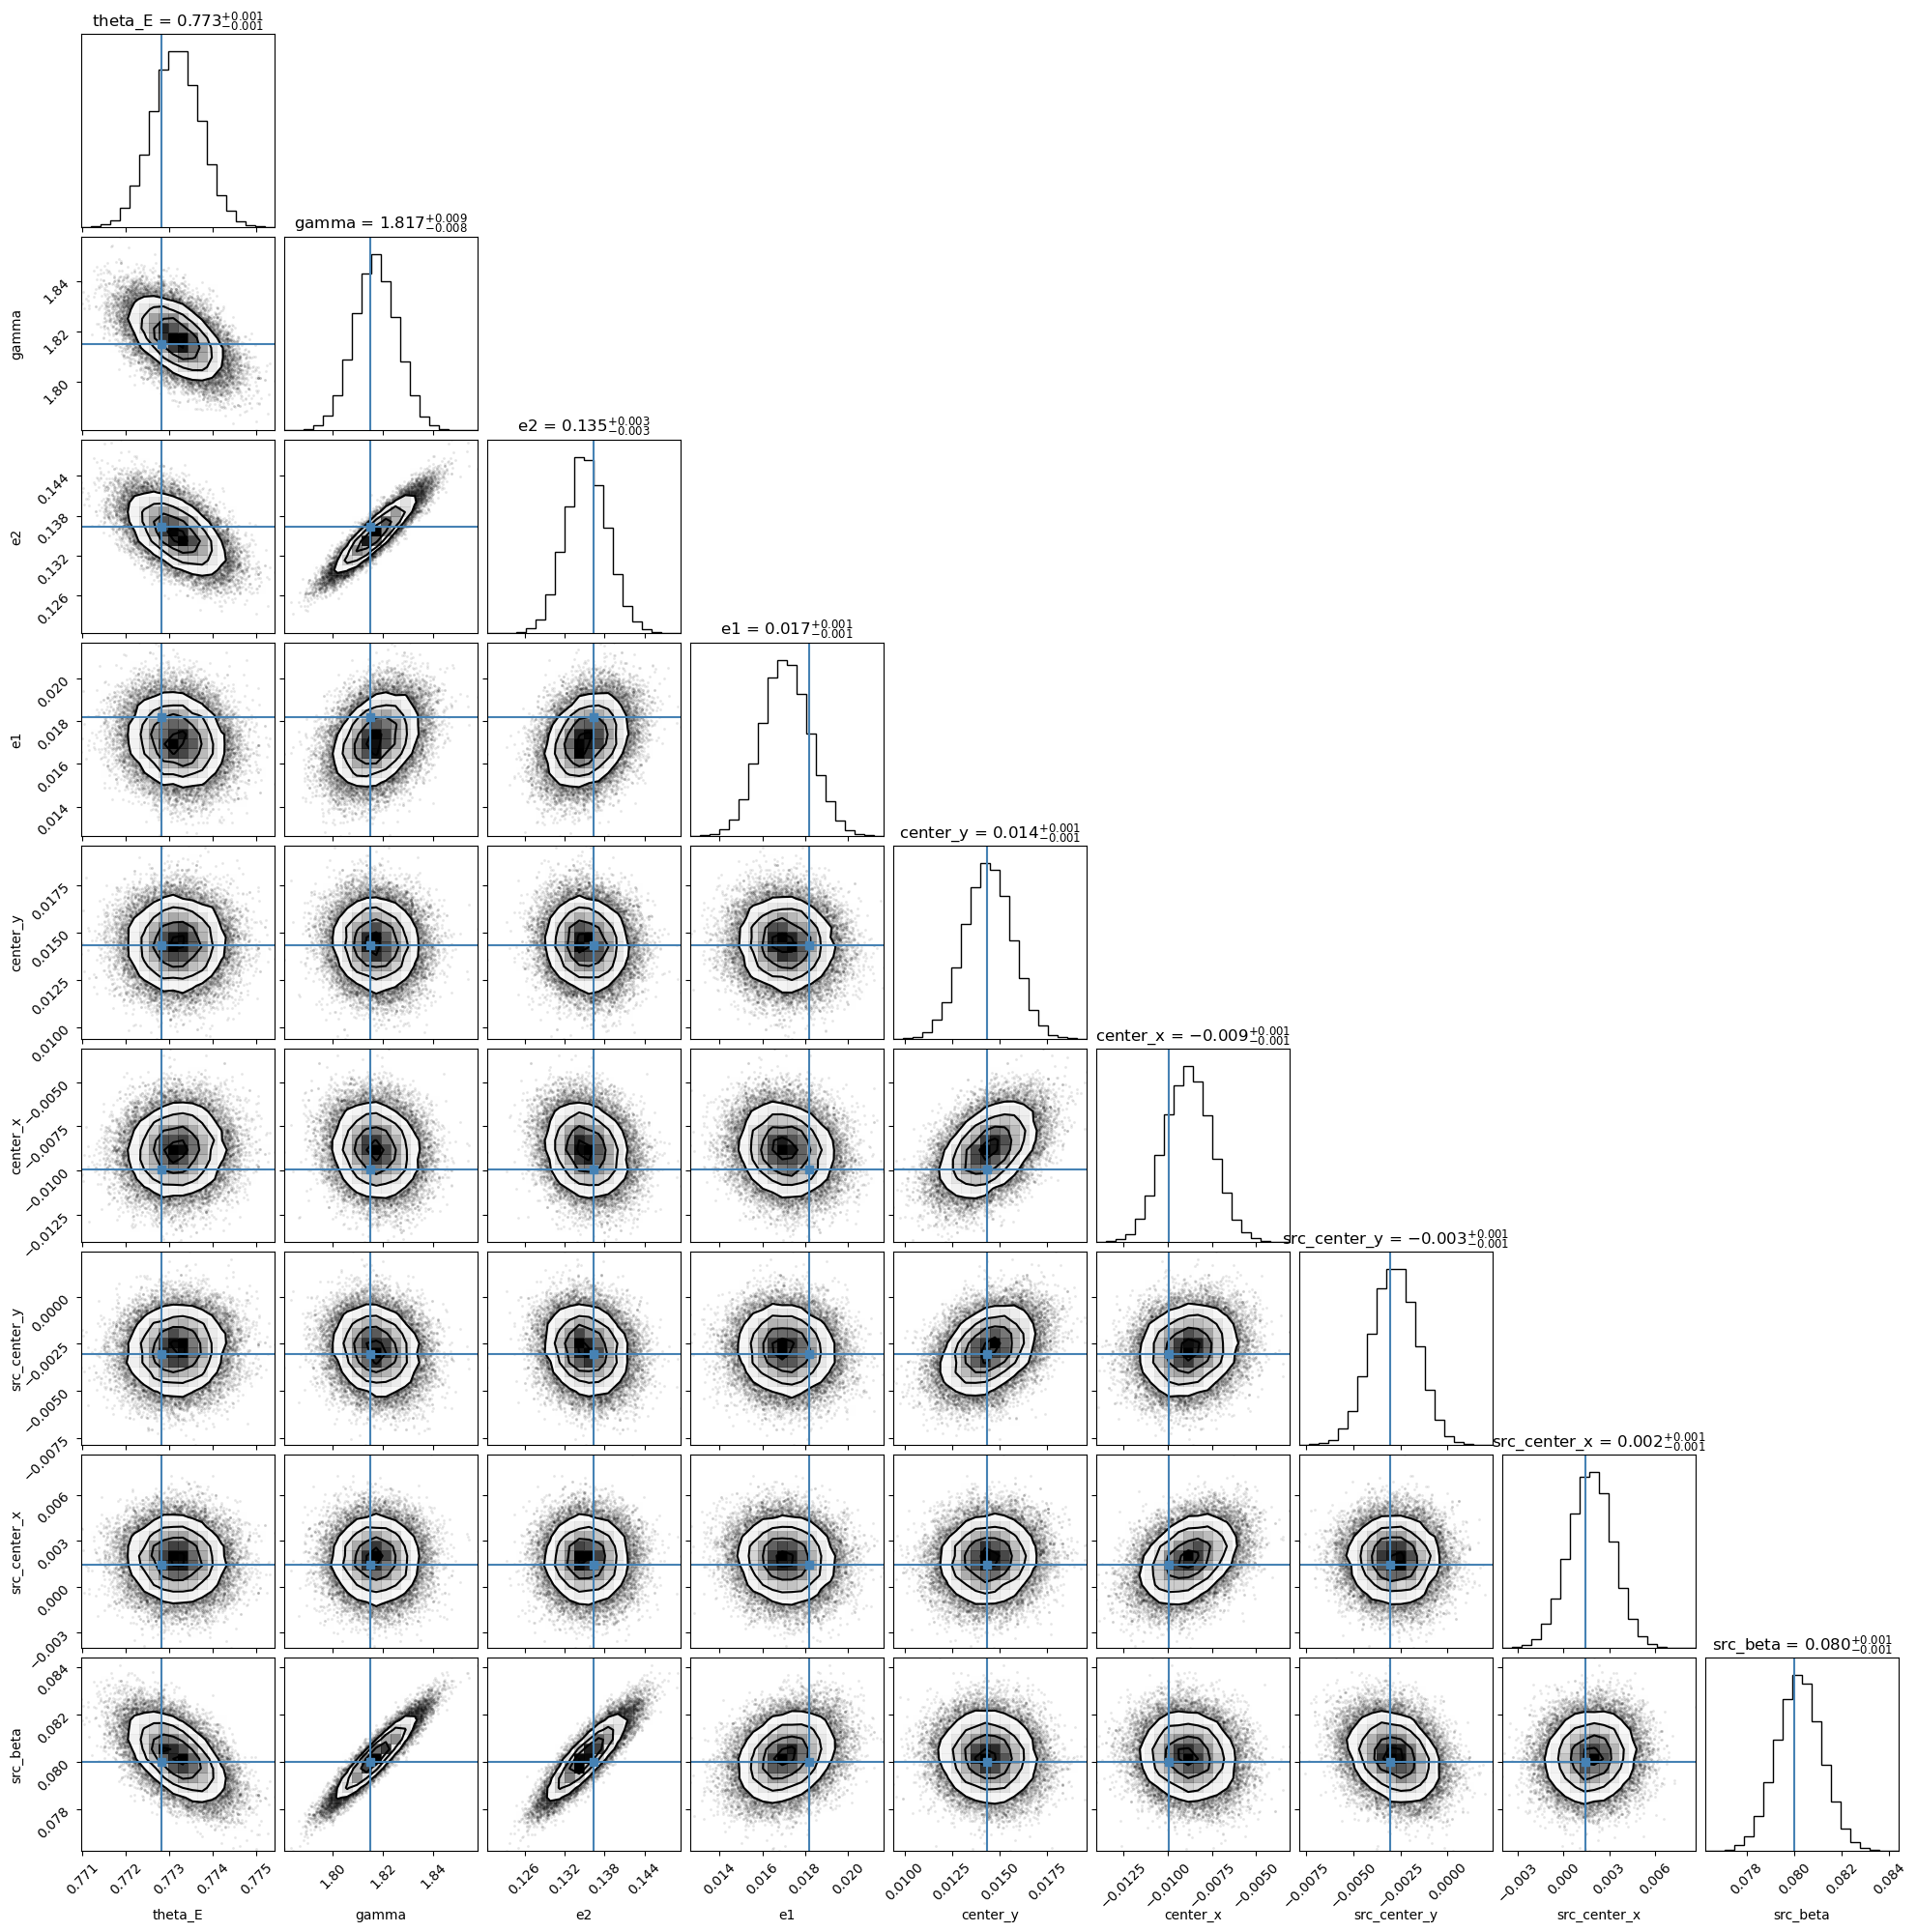

In [22]:
fig = corner(plt_samples, show_titles=True, title_fmt='.3f', labels=labels, truths=markers)

Visualize the result:

2026-02-15 18:51:46.558074: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


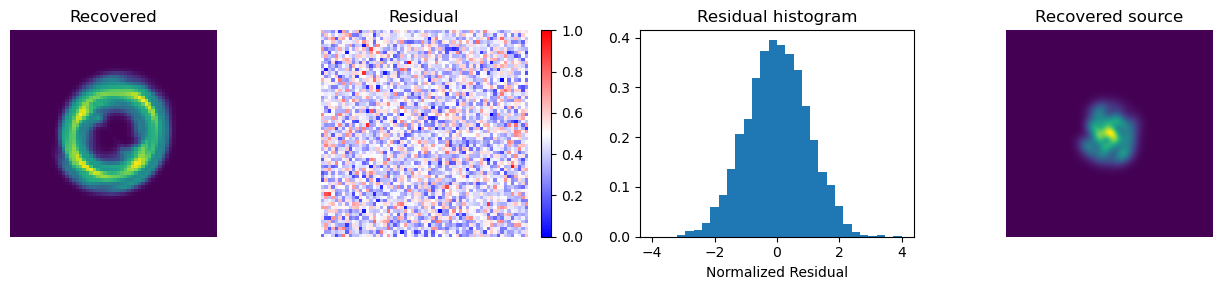

In [23]:
mean_estimate= [[{key:jnp.mean(value) for key,value in par.items()} for par in cat]for cat in smp_physical]

residual = (observed_img-lens_sim.lstsq_simulate(mean_estimate, observed_img, err_map)[0])/err_map 

coeffs = lens_sim.lstsq_simulate(mean_estimate, observed_img, err_map)[1]
shp = shapelets.Shapelets(n_max=n_max, interpolate=False, use_lstsq=False)
grid = jnp.linspace(-1,1,1000).astype(jnp.float32)
a, b = jnp.meshgrid(grid,grid)
ret = shp.light(a[np.newaxis,...,np.newaxis], b[np.newaxis,...,np.newaxis], **mean_estimate[1][0], 
               **{shp._amp_names[i]: jnp.array([coeffs[i]]) for i in range(shp.depth)})

fig, ax = plt.subplots(1,4,figsize=(13,3))

ax[0].set_title('Recovered')
ax[0].imshow(lens_sim.lstsq_simulate(mean_estimate, observed_img, err_map)[0])
ax[0].set_axis_off()

ax[1].set_title('Residual')
ax[1].imshow(residual, cmap='bwr', interpolation='none')
fig.colorbar(mpl.cm.ScalarMappable(cmap='bwr'),ax=ax[1])
ax[1].set_axis_off()

ax[2].set_title('Residual histogram')
ax[2].hist(residual.flatten(), range=(-4,4), density=True, bins=30)
ax[2].set_xlabel('Normalized Residual')

ax[3].set_title('Recovered source')
ax[3].imshow(jnp.squeeze(ret))
ax[3].set_axis_off()
fig.tight_layout()